# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [1]:
# Load the libraries as required.
# Load the libraries as required.
%load_ext dotenv
%dotenv 
import os
import sys
sys.path.append(os.getenv('SRC_DIR'))
from utils.logger import get_logger
_logs = get_logger(__name__)
import dask.dataframe as dd
import pandas as pd
import numpy as np
import os
from glob import glob

In [2]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


# Get X and Y

Create the features data frame and target data.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import make_scorer, log_loss, roc_auc_score, f1_score, accuracy_score, precision_score, recall_score

# Preprocess the data
X = fires_dt.drop(columns=['area'])
y = fires_dt['area']


In [4]:
# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [5]:
# Import necessary libraries for preprocessing and modeling
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.naive_bayes import GaussianNB

In [6]:
#indetify the categorical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
#indentify the numerical columns
num_cols = X.select_dtypes(include=['number']).columns.tolist()

num_transformers_preprocessor1 = StandardScaler()
cat_transformers_preprocessor1 = OneHotEncoder(handle_unknown='ignore')

Preproc1 = ColumnTransformer(
    transformers=[
        ('num', num_transformers_preprocessor1, num_cols),
        ('cat', cat_transformers_preprocessor1, cat_cols)
    ],
    remainder='passthrough'
)

In [7]:
X[num_cols].skew()

coord_x     0.036246
coord_y     0.417296
ffmc       -6.575606
dmc         0.547498
dc         -1.100445
isi         2.536325
temp       -0.331172
rh          0.862904
wind        0.571001
rain       19.816344
dtype: float64

### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [8]:
# Apply a non-linear transformation to the skewed numerical columns as per the skewness
non_linear_cols = ['ffmc', 'rain']
cols_for_scaling = [col for col in num_cols if col not in non_linear_cols]


num_transformers_preprocessor2 = StandardScaler()
cat_transformers_preprocessor2 = OneHotEncoder(handle_unknown='ignore')
non_linear_transformer_preproc2 = PowerTransformer(method='yeo-johnson')

Preproc2 = ColumnTransformer(
    transformers=[
        # Reusing the numerical transformer from preproc1
        ('num', num_transformers_preprocessor2, cols_for_scaling),
        ('non_linear', non_linear_transformer_preproc2, non_linear_cols),
        # Reusing the categorical transformer from preproc1 
        ('cat', cat_transformers_preprocessor2, cat_cols)
    ],
    remainder='passthrough'
)

## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [9]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold

In [10]:
# Pipeline A = preproc1 + baseline
pipeline_A = Pipeline(steps=[
    ('preprocessor', Preproc1),
    ('regressor', Ridge(random_state=42))
])


In [11]:
# Pipeline B = preproc2 + baseline
pipeline_B = Pipeline(steps=[
    ('preprocessor', Preproc2),
    ('regressor', Ridge(random_state=42))
])

In [12]:
# Pipeline C = preproc1 + advanced model
from sklearn.ensemble import RandomForestRegressor

pipeline_C = Pipeline(steps=[
    ('preprocessor', Preproc1),
    ('regressor', RandomForestRegressor(random_state=42, n_estimators=100))
])


In [13]:
# Pipeline D = preproc2 + advanced model
pipeline_D = Pipeline(steps=[
    ('preprocessor', Preproc2),
    ('regressor', RandomForestRegressor(random_state=42, n_estimators=100))
])
    

# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [14]:
# Tune the hyperparameters and Experiment with at least four value combinations of the model A

param_grid_A = {
    'regressor__alpha': [0.1, 1.0, 10.0, 100.0]
}
grid_search_A = GridSearchCV(pipeline_A, 
                             param_grid=param_grid_A, 
                             cv=KFold(n_splits=5, shuffle=True, random_state=42), 
                             scoring='neg_mean_squared_error')
# Fit the model
grid_search_A.fit(X_train, Y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['coord_x',
                                                                          'coord_y',
                                                                          'ffmc',
                                                                          'dmc',
                                                                          'dc',
                                                                          'isi',
                                                                          'temp',
                                                                          'rh',
                                                                          'wind',
                                                                          'rain']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['month',
                                                                          'day'])])),
                                       ('regressor', Ridge(random_state=42))]),
             param_grid={'regressor__alpha': [0.1, 1.0, 10.0, 100.0]},
             scoring='neg_mean_squared_error')

In [15]:
# Tune the hyperparameters and Experiment with at least four value combinations of the model B
param_grid_B = {
    'regressor__alpha': [0.1, 1.0, 10.0, 100.0]
}
grid_search_B = GridSearchCV(pipeline_B, 
                             param_grid=param_grid_B, 
                             cv=KFold(n_splits=5, shuffle=True, random_state=42), 
                             scoring='neg_mean_squared_error')
# it the model
grid_search_B.fit(X_train, Y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['coord_x',
                                                                          'coord_y',
                                                                          'dmc',
                                                                          'dc',
                                                                          'isi',
                                                                          'temp',
                                                                          'rh',
                                                                          'wind']),
                                                                        ('non_linear',
                                                                         PowerTransformer(),
                                                                         ['ffmc',
                                                                          'rain']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['month',
                                                                          'day'])])),
                                       ('regressor', Ridge(random_state=42))]),
             param_grid={'regressor__alpha': [0.1, 1.0, 10.0, 100.0]},
             scoring='neg_mean_squared_error')

In [16]:
# Tune the hyperparameters and Experiment with at least four value combinations of the model C
param_grid_C = {
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]
}
grid_search_C = GridSearchCV(pipeline_C,
                             param_grid=param_grid_C, 
                             cv=KFold(n_splits=5, shuffle=True, random_state=42), 
                             scoring='neg_mean_squared_error')
# Fit the model
grid_search_C.fit(X_train, Y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['coord_x',
                                                                          'coord_y',
                                                                          'ffmc',
                                                                          'dmc',
                                                                          'dc',
                                                                          'isi',
                                                                          'temp',
                                                                          'rh',
                                                                          'wind',
                                                                          'rain']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['month',
                                                                          'day'])])),
                                       ('regressor',
                                        RandomForestRegressor(random_state=42))]),
             param_grid={'regressor__max_depth': [None, 10, 20, 30],
                         'regressor__min_samples_leaf': [1, 2, 4],
                         'regressor__min_samples_split': [2, 5, 10]},
             scoring='neg_mean_squared_error')

In [17]:
# Tune the hyperparameters and Experiment with at least four value combinations of the model D 
param_grid_D = {
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]
}
grid_search_D = GridSearchCV(pipeline_D,
                             param_grid=param_grid_D, 
                             cv=KFold(n_splits=5, shuffle=True, random_state=42), 
                             scoring='neg_mean_squared_error')
# Fit the model
grid_search_D.fit(X_train, Y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['coord_x',
                                                                          'coord_y',
                                                                          'dmc',
                                                                          'dc',
                                                                          'isi',
                                                                          'temp',
                                                                          'rh',
                                                                          'wind']),
                                                                        ('non_linear',
                                                                         PowerTransformer(),
                                                                         ['ffmc',
                                                                          'rain']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['month',
                                                                          'day'])])),
                                       ('regressor',
                                        RandomForestRegressor(random_state=42))]),
             param_grid={'regressor__max_depth': [None, 10, 20, 30],
                         'regressor__min_samples_leaf': [1, 2, 4],
                         'regressor__min_samples_split': [2, 5, 10]},
             scoring='neg_mean_squared_error')

# Evaluate

+ Which model has the best performance?

# Export

+ Save the best performing model to a pickle file.

In [18]:
evaluted_models = {
    'Model-A': grid_search_A,
    'Model-B': grid_search_B,
    'Model-C': grid_search_C,
    'Model-D': grid_search_D
}
# Evaluate the models using cross-validation and store the results
results = {}
for model_name, grid_search in evaluted_models.items():
    results[model_name] = {
        'best_score': grid_search.best_score_,
        'best_params': grid_search.best_params_
    }
# Display the results
results_df = pd.DataFrame(results).T
results_df.sort_values(by='best_score', ascending=False, inplace=True)
print("Model Evaluation Results:")
print(results_df)

Model Evaluation Results:
          best_score                                        best_params
Model-B -2112.339596                        {'regressor__alpha': 100.0}
Model-A -2174.568706                        {'regressor__alpha': 100.0}
Model-C -2258.698683  {'regressor__max_depth': None, 'regressor__min...
Model-D -2259.461608  {'regressor__max_depth': None, 'regressor__min...


In [19]:
import pickle
import os # For managing file paths

model_filename = 'best_model.pkl'
try:
    with open(model_filename, 'wb') as file:
        pickle.dump(grid_search_B, file)
    print(f"Model successfully saved to {model_filename}")
except Exception as e:
    print(f"Error saving model: {e}")

Model successfully saved to best_model.pkl


# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

/var/folders/3f/syr_nks50bj73pf7lv_7j5pw0000gn/T/ipykernel_43913/3329227903.py:2: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, 'bool'):
/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


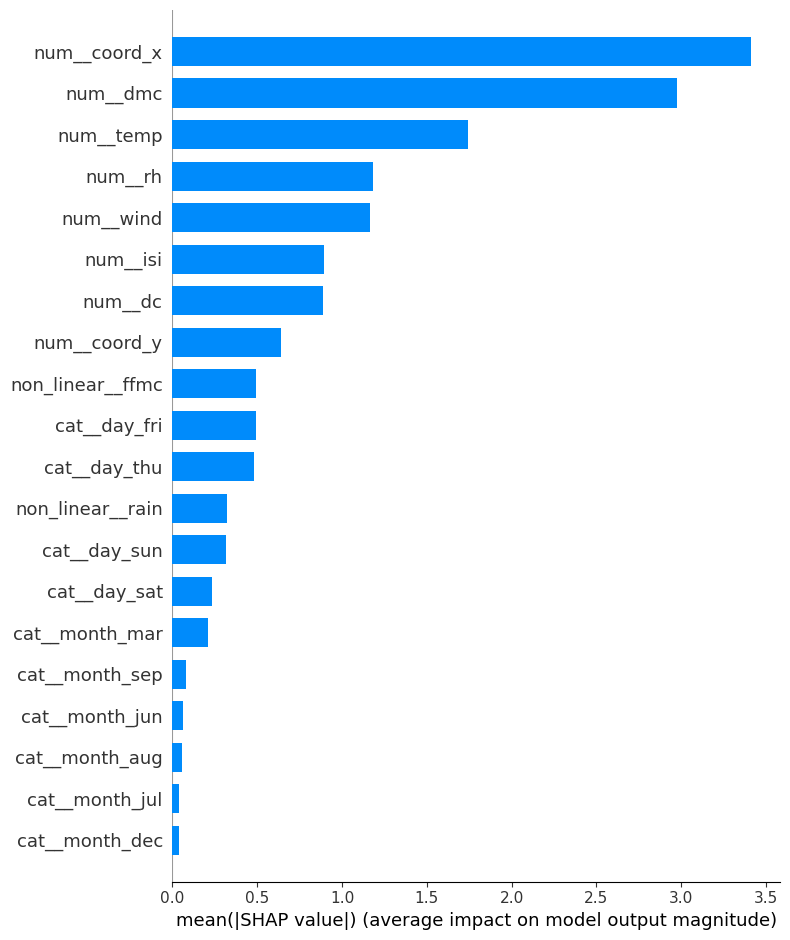

In [20]:
import numpy as np
if not hasattr(np, 'bool'):
    np.bool = bool

import shap
# Load the best model (GridSearchCV object)
with open(model_filename, 'rb') as file:
    grid_search_B = pickle.load(file)

# Get the best pipeline from GridSearchCV
pipeline_B = grid_search_B.best_estimator_

# Prepare the data for SHAP
X_test = X_test.copy()
data_transform = pipeline_B.named_steps['preprocessor'].transform(X_test)

explainer = shap.explainers.Linear(
    pipeline_B.named_steps['regressor'], 
    data_transform,
    feature_names=pipeline_B.named_steps['preprocessor'].get_feature_names_out()
)

shap_values = explainer(data_transform)

shap_values.shape
# Visualize the SHAP values
shap.summary_plot(shap_values, 
                   features=data_transform, 
                   feature_names=pipeline_B.named_steps['preprocessor'].get_feature_names_out(),
                   plot_type='bar')

In [21]:
#As per the SHAP values, the most important features are:
important_features = pd.DataFrame({
    'Feature': pipeline_B.named_steps['preprocessor'].get_feature_names_out(),
    'SHAP Value': np.abs(shap_values.values).mean(axis=0)
}).sort_values(by='SHAP Value', ascending=False)
print("Most Important Features based on SHAP values:")
print(important_features.head(10))

Most Important Features based on SHAP values:
             Feature  SHAP Value
0       num__coord_x    3.411754
2           num__dmc    2.976437
5          num__temp    1.741469
6            num__rh    1.180113
7          num__wind    1.166424
4           num__isi    0.892546
3            num__dc    0.889187
1       num__coord_y    0.640854
8   non_linear__ffmc    0.493693
22      cat__day_fri    0.493153


*(Answer here.)*

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.